<a href="https://colab.research.google.com/github/hrley55/BIG-DATA-NHOM-7/blob/main/Regression_Ph%C3%A2n_t%C3%ADch_k%E1%BA%BFt_qu%E1%BA%A3_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Đang tải dataset trực tiếp từ Kaggle...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Đang đọc và gộp dữ liệu...

Bắt đầu huấn luyện mô hình (Có thể mất vài phút cho Random Forest)...

--- LinearRegression ---
Tham số tốt nhất: {'regressor__fit_intercept': True}
Thời gian huấn luyện: 6.47 giây
MAE: 3.6967
RMSE: 4.7542
R2 Score: 0.1208

--- DecisionTreeRegressor ---
Tham số tốt nhất: {'regressor__max_depth': 10, 'regressor__min_samples_split': 20}
Thời gian huấn luyện: 10.92 giây
MAE: 3.6340
RMSE: 4.6686
R2 Score: 0.1522

--- RandomForestRegressor ---
Tham số tốt nhất: {'regressor__max_depth': 20, 'regressor__max_features': 'sqrt', 'regressor__n_estimators': 100}
Thời gian huấn luyện: 315.19 giây
MAE: 3.4576
RMSE: 4.4962
R2 Score: 0.2137


/tmp/ipykernel_13887/3629364930.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


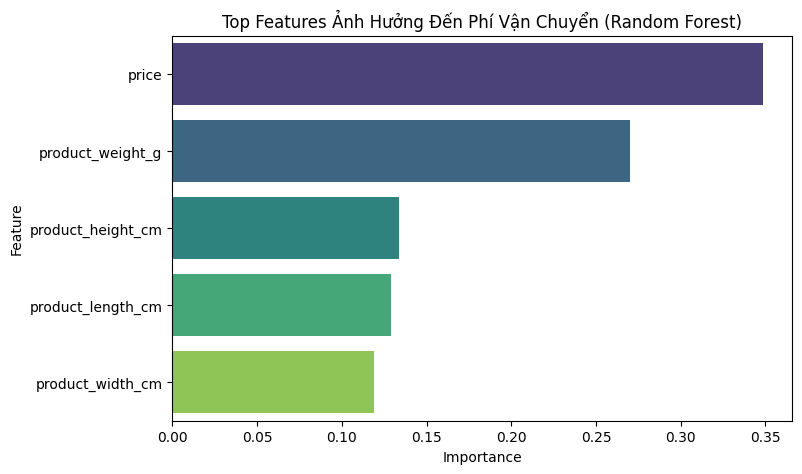

In [ ]:
import pandas as pd
import numpy as np
import os
import time # Thêm thư viện time để đo thời gian
import kagglehub
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Thêm MAE

# ==========================================
# BƯỚC 1 & 2: TẢI DATA TỪ KAGGLE VÀ GỘP DỮ LIỆU
# ==========================================
print("Đang tải dataset trực tiếp từ Kaggle...")
dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Đang đọc và gộp dữ liệu...")
items_df = pd.read_csv(os.path.join(dataset_path, 'olist_order_items_dataset.csv'))
products_df = pd.read_csv(os.path.join(dataset_path, 'olist_products_dataset.csv'))

df = pd.merge(items_df, products_df, on='product_id', how='inner')

features = ['price', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
target = 'freight_value'

df = df[features + [target]].dropna()

# ==========================================
# BƯỚC 3: XỬ LÝ OUTLIER BẰNG IQR
# ==========================================
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df = remove_outliers_iqr(df, 'freight_value')
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'product_weight_g')

# ==========================================
# BƯỚC 4: CHIA TẬP DỮ LIỆU (TRAIN/TEST SPLIT)
# ==========================================
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# BƯỚC 5 & 6: XÂY DỰNG PIPELINE VÀ TRAINING
# ==========================================
models_configs = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {
            "regressor__fit_intercept": [True, False]
        }
    },
    "DecisionTreeRegressor": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "regressor__max_depth": [None, 10, 20, 30],
            "regressor__min_samples_split": [2, 10, 20]
        }
    },
    "RandomForestRegressor": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "regressor__n_estimators": [50, 100],
            "regressor__max_depth": [None, 10, 20],
            "regressor__max_features": ['sqrt', 'log2', 1.0]
        }
    }
}

results = {}

print("\nBắt đầu huấn luyện mô hình (Có thể mất vài phút cho Random Forest)...")
for name, config in models_configs.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', config['model'])
    ])

    grid = GridSearchCV(pipeline, config['params'], cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

    # Bắt đầu đo thời gian huấn luyện
    start_time = time.time()
    grid.fit(X_train, y_train)
    end_time = time.time()

    # Tính toán thời gian chạy (tính bằng giây)
    train_time = end_time - start_time

    # Dự đoán trên tập Test
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # Đánh giá các chỉ số
    mae = mean_absolute_error(y_test, y_pred) # Tính MAE
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Lưu kết quả
    results[name] = {
        "Best Params": grid.best_params_,
        "Train Time (s)": train_time,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

    # In kết quả ra màn hình
    print(f"\n--- {name} ---")
    print(f"Tham số tốt nhất: {grid.best_params_}")
    print(f"Thời gian huấn luyện: {train_time:.2f} giây")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử 'grid' là biến lưu GridSearchCV của Random Forest ở code trước
best_rf = results['RandomForestRegressor']['Best Params'] # Lấy model tốt nhất
# Hoặc gọi thẳng mô hình nếu bạn đã train riêng: best_rf = grid.best_estimator_.named_steps['regressor']

importances = grid.best_estimator_.named_steps['regressor'].feature_importances_
feature_names = features # ['price', 'product_weight_g', ...]

# Tạo DataFrame và vẽ
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top Features Ảnh Hưởng Đến Phí Vận Chuyển (Random Forest)')
plt.show()

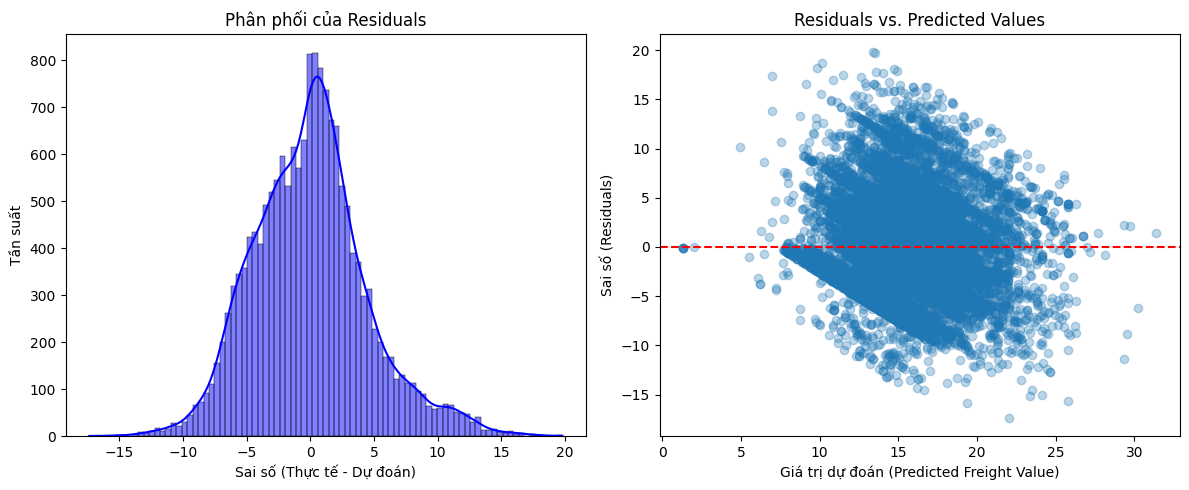

In [ ]:
# Tính sai số (Residuals)
residuals = y_test - y_pred # y_pred của Random Forest

plt.figure(figsize=(12, 5))

# 1. Biểu đồ phân phối sai số (Histogram)
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='blue')
plt.title('Phân phối của Residuals')
plt.xlabel('Sai số (Thực tế - Dự đoán)')
plt.ylabel('Tần suất')

# 2. Biểu đồ Scatter Plot kiểm tra Heteroscedasticity
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Giá trị dự đoán (Predicted Freight Value)')
plt.ylabel('Sai số (Residuals)')

plt.tight_layout()
plt.show()